In [18]:
!pip install scipy scikit-learn pandas numpy

In [19]:
import pandas as pd
import numpy as np
import json

from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
from google.colab import files

uploaded = files.upload()

In [20]:
dynamic_gt = pd.read_csv("CareerCorpus_DynamicGT.csv")

eval_df = pd.read_csv("evaluation_results.csv")

with open("complete_pipeline_results.json", "r") as f:
    json_results = json.load(f)

print("Dynamic GT Shape:", dynamic_gt.shape)
print("Evaluation CSV Shape:", eval_df.shape)
print("JSON Records:", len(json_results))

Dynamic GT Shape: (302, 12)
Evaluation CSV Shape: (302, 6)
JSON Records: 302


In [21]:
print("Dynamic GT Columns:")
print(dynamic_gt.columns)

print("\nEvaluation CSV Columns:")
print(eval_df.columns)

print("\nSample JSON Keys:")
print(json_results[0].keys())

Dynamic GT Columns:
Index(['ID', 'Domain', 'Education', 'Skills and Achievements', 'Experience',
       'Job_type', 'Annotator-1', 'Annotator-2', 'Resume_Text',
       'Weight_Annotator1', 'Weight_Annotator2', 'Dynamic_GT'],
      dtype='object')

Evaluation CSV Columns:
Index(['resume_id', 'domain', 'predicted_score', 'ground_truth_score',
       'decision', 'confidence'],
      dtype='object')

Sample JSON Keys:
dict_keys(['resume_id', 'domain', 'target_job', 'resume_evaluator', 'ceo_review', 'cto_review', 'hr_review', 'final_result', 'ground_truth_score'])


In [22]:
# Convert Dynamic Ground Truth from 0-1 to 0-10

dynamic_gt["Dynamic_GT"] = dynamic_gt["Dynamic_GT"] * 10

dynamic_gt[["ID", "Dynamic_GT"]].head()

,ID,Dynamic_GT
0,74552449,8.611765
1,79041971,6.439394
2,77156708,9.338889
3,24580361,9.022581
4,34953092,8.486956


In [23]:
# Create mapping from Resume ID to Dynamic Ground Truth

gt_map = dict(zip(dynamic_gt["ID"], dynamic_gt["Dynamic_GT"]))

print("Total IDs:", len(gt_map))

Total IDs: 301


In [26]:
# Replace old average GT with Dynamic GT (same row order)

eval_df["ground_truth_score"] = dynamic_gt["Dynamic_GT"].values

eval_df.head()

,resume_id,domain,predicted_score,ground_truth_score,decision,confidence
0,NaN,Banking,6.0,8.611765,Hire,7.0
1,NaN,Banking,6.0,6.439394,Hold,7.0
2,NaN,Banking,7.1,9.338889,Hold,8.0
3,NaN,Banking,6.0,9.022581,Hold,7.0
4,NaN,Banking,7.0,8.486956,Hire,7.0


In [27]:
print(eval_df["ground_truth_score"].isnull().sum())

0


In [28]:
# Save updated evaluation CSV

eval_df.to_csv(
    "evaluation_results_dynamicGT.csv",
    index=False
)

print("Updated evaluation_results_dynamicGT.csv saved successfully!")

Updated evaluation_results_dynamicGT.csv saved successfully!


In [29]:
# Replace old ground truth in JSON with Dynamic Ground Truth

for i, item in enumerate(json_results):

    item["ground_truth_score"] = float(
        dynamic_gt.loc[i, "Dynamic_GT"]
    )

print("JSON updated successfully!")

JSON updated successfully!


In [30]:
# Save updated JSON with Dynamic Ground Truth

with open(
    "complete_pipeline_results_dynamicGT.json",
    "w"
) as f:

    json.dump(
        json_results,
        f,
        indent=4
    )

print("Updated JSON saved successfully!")

Updated JSON saved successfully!


In [31]:
# Prepare arrays for evaluation

y_true = eval_df["ground_truth_score"].astype(float).values
y_pred = eval_df["predicted_score"].astype(float).values

print("Total Samples:", len(y_true))
print("Ground Truth Range:", y_true.min(), "to", y_true.max())
print("Prediction Range:", y_pred.min(), "to", y_pred.max())

Total Samples: 302
Ground Truth Range: 0.245945962600436 to 9.633333338888884
Prediction Range: 2.5 to 8.8


In [32]:
# Overall Pearson Correlation

pearson_corr, p_value = pearsonr(y_true, y_pred)

print(f"Pearson Correlation : {pearson_corr:.4f}")
print(f"P-value             : {p_value:.6f}")

Pearson Correlation : 0.6149
P-value             : 0.000000


In [33]:
# Overall Spearman Correlation

spearman_corr, p_value = spearmanr(y_true, y_pred)

print(f"Spearman Correlation : {spearman_corr:.4f}")
print(f"P-value              : {p_value:.6f}")

Spearman Correlation : 0.6466
P-value              : 0.000000


In [34]:
# ------------------------------------------------------------
# Percentile Metrics (Paper Method)
# ------------------------------------------------------------

def percentile_metrics(df, percentile):

    gt = df["ground_truth_score"]
    pred = df["predicted_score"]

    lower = np.percentile(gt, percentile)
    upper = np.percentile(gt, 100 - percentile)

    subset = df[
        (gt <= lower) |
        (gt >= upper)
    ]

    pc, _ = pearsonr(
        subset["ground_truth_score"],
        subset["predicted_score"]
    )

    sc, _ = spearmanr(
        subset["ground_truth_score"],
        subset["predicted_score"]
    )

    return pc, sc

In [35]:
# ------------------------------------------------------------
# Percentile-Based Correlation Metrics
# ------------------------------------------------------------

PC20, SC20 = percentile_metrics(eval_df, 20)

PC15, SC15 = percentile_metrics(eval_df, 15)

PC10, SC10 = percentile_metrics(eval_df, 10)

print(f"PC20 = {PC20:.4f}")
print(f"SC20 = {SC20:.4f}")

print()

print(f"PC15 = {PC15:.4f}")
print(f"SC15 = {SC15:.4f}")

print()

print(f"PC10 = {PC10:.4f}")
print(f"SC10 = {SC10:.4f}")

PC20 = 0.7396
SC20 = 0.7463

PC15 = 0.7875
SC15 = 0.7569

PC10 = 0.8499
SC10 = 0.7793


In [36]:
# ------------------------------------------------------------
# Error Metrics
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

r2 = r2_score(
    y_true,
    y_pred
)

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

MAE  = 1.5508
RMSE = 1.7792
R²   = 0.1031


In [38]:
import matplotlib.pyplot as plt
import numpy as np

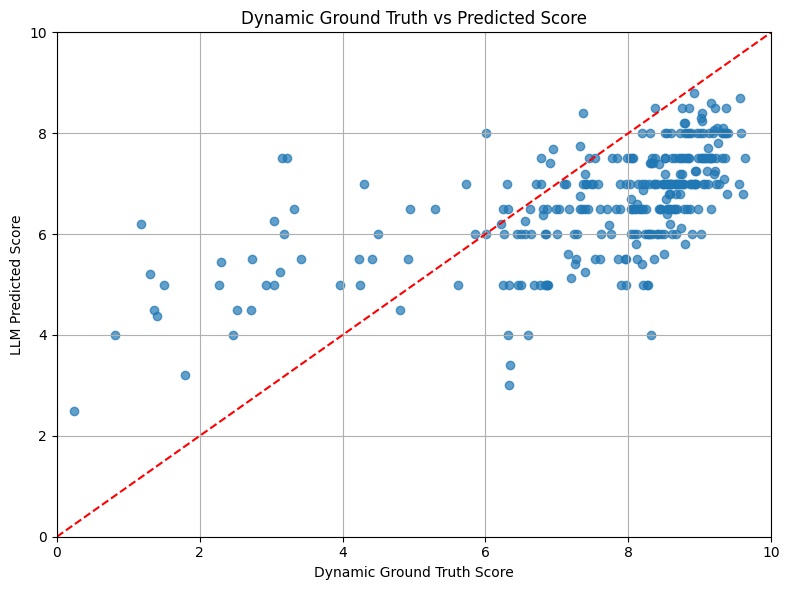

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    eval_df["ground_truth_score"],
    eval_df["predicted_score"],
    alpha=0.7
)

plt.plot([0,10],[0,10],'r--')

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("LLM Predicted Score")
plt.title("Dynamic Ground Truth vs Predicted Score")

plt.xlim(0,10)
plt.ylim(0,10)

plt.grid(True)

plt.tight_layout()
plt.show()


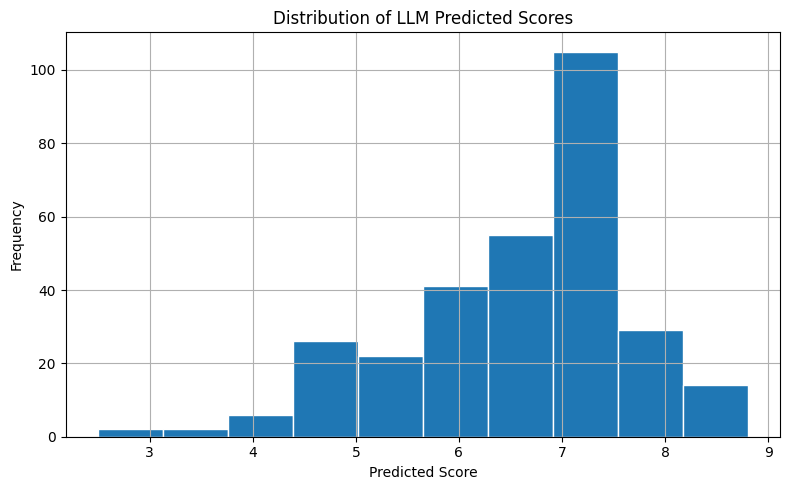

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    eval_df["predicted_score"],
    bins=10,
    edgecolor="white"
)

plt.xlabel("Predicted Score")
plt.ylabel("Frequency")
plt.title("Distribution of LLM Predicted Scores")

plt.grid(True)

plt.tight_layout()
plt.show()

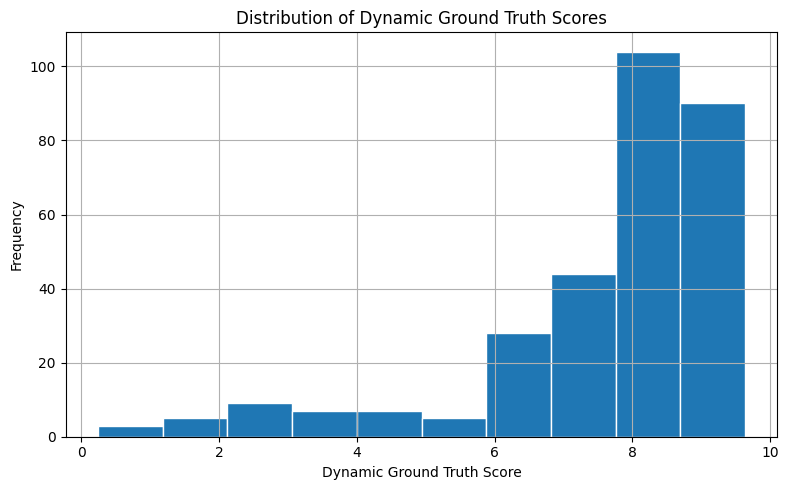

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    eval_df["ground_truth_score"],
    bins=10,
    edgecolor="white"
)

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("Frequency")
plt.title("Distribution of Dynamic Ground Truth Scores")

plt.grid(True)

plt.tight_layout()
plt.show()

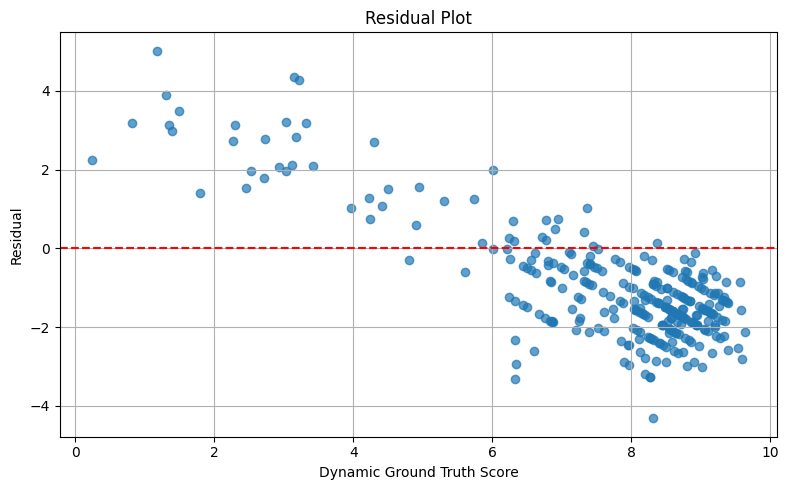

In [42]:
residuals = (
    eval_df["predicted_score"] -
    eval_df["ground_truth_score"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    eval_df["ground_truth_score"],
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Dynamic Ground Truth Score")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.tight_layout()
plt.show()

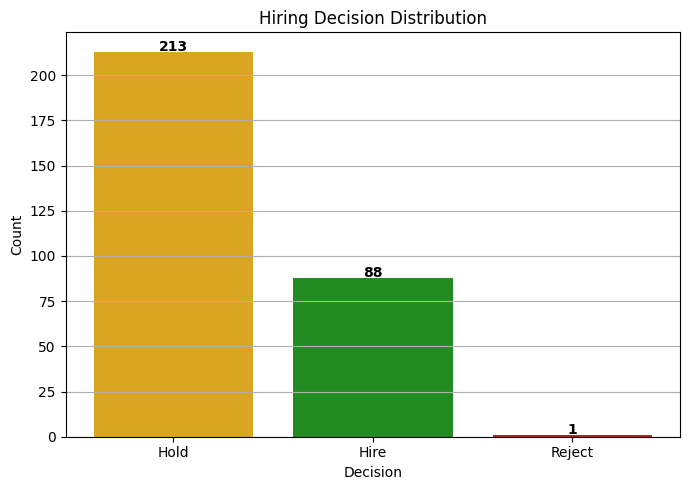

In [43]:
decision_counts = eval_df["decision"].value_counts()

colors = {
    "Hire": "forestgreen",
    "Hold": "goldenrod",
    "Reject": "firebrick"
}

plt.figure(figsize=(7,5))

bars = plt.bar(
    decision_counts.index,
    decision_counts.values,
    color=[colors.get(i, "gray") for i in decision_counts.index]
)

plt.xlabel("Decision")
plt.ylabel("Count")
plt.title("Hiring Decision Distribution")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center',
        fontweight='bold'
    )

plt.grid(axis='y')

plt.tight_layout()
plt.show()